Reproducing a symmetrical, global model of the lunar dust cloud from the paper "A permanent, asymmetric dust cloud around the Moon" published in the Nature journal.

In [4]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import dblquad
import os

# Constants
G = 6.67e-11 #m^3/kg/s^2
M = 7.735e22 #kg
R = 1.737e6 #m
Fimp = 11.6e-15 #kg/m^2/s
Y = 1000 # ratio of ejecta mass to impactor mass
S = pi*R**2 # cross-sectional area of the Moon
pi = np.pi

# Parameters
alpha = 0.91 #mass distribution exponent
mmin = 3e-16 #kg
mmax = 1e-8 #kg
mew = 3.4 #initial velocity distribution exponent
umax = 4800 #m/s, maximum initial velocity of dust grains
Mplus = Fimp * Y * S #total mass of ejecta produced per second

psi0 = pi/6 #radians

# Setting up variables
m, v, r, theta, phi = symbols('m v r theta phi', real=True, positive=True)

# Defining equation for initial velocity
h = r-R
u = sqrt(v**2 + 2*G*M*(1/R - 1/r)) 

# Defining equation for minimum initial velocity at certain altitude
u0 = sqrt(2*G*M*(1/R - 1/r)) # v = 0ms^-1

# Defining equation for distribution of initial velocities
fu = ((mew-1)/(u0**(1-mew)))*(u**(-mew)) # distriubtion sourced from nature paper

# Defining equation for ejection cone angle
psi = asin(((r*v) / (R*u)) * sin(theta)) # calculating ejection angle using concept of conservation of angular momentum

# Defining equation for distribution of ejection angles
fpsi = (sin(psi))/(1-cos(psi0)) # distribution sourced from nature paper

# Defining the distribution of the rate of grains produced
mdist = Mplus*(1-alpha)/(mmax**(1-alpha)-mmin**(1-alpha)) * m**(-alpha-1) # distribution sourced from nature paper
Nplus = integrate(mdist, m) # integrating over mass to get the total number of grains produced per second
Nplus = Nplus.subs(m, mmax) - Nplus.subs(m, mmin) # substituting the limits of integration given in nature paper

# Phase space density of dust above surface
n = Nplus / (8*pi*R*r) * (fu*fpsi) / (v*u**2*sin(theta)*cos(psi)) # equation 2 from nature paper, function of v, r, theta, phi
n = n*2*pi # Integrating over phi

nFunc = lambdify((v, r, theta), n) # converting the symbolic expression to a numerical function to make substitutions easier


Directory 'Plots' already exists. Plot will be saved in this directory.


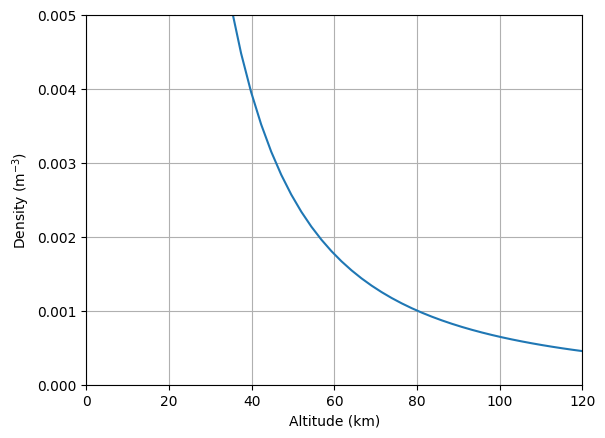

In [5]:
def calculateThetaMax(r_val):
    # Function to calculate the maximum ejection angle at a given distance from centre, r_val,
    # using the conservation of angular momentum
    vmax = sqrt(umax**2+2*G*M*(1/r_val - 1/R)) # using conservation of energy to calculate the maximum velocity at a given distance
    thetamax = asin(sin(psi0)*R*umax/(r_val*vmax)) # using conservation of angular momentum to calculate the maximum ejection angle at a given distance
    return thetamax

def calculateDensity(r_val):
    # Function to calculate the density of dust grains at a given distance from centre, r_val
    vmax = sqrt(umax**2+2*G*M*(1/r_val - 1/R)) # using conservation of energy to calculate the maximum velocity at a given distance
    density, error = dblquad(lambda v, theta: nFunc(v, r_val, theta), 0, vmax, 0, calculateThetaMax(r_val)) # integrating over the velocity and ejection angle to get the total density at a given distance

    return density*2 # multiplying by 2 to account for the fact that the integration only covers half of the ejection cone

# Plotting the density of dust grains above the Moon's surface
x = np.linspace(1, 120, 50)
y = [calculateDensity(h*1000+R) for h in x] # calculating the density at each height above the Moon's surface (1km increments)
plt.plot(x, y)
plt.xlabel('Altitude (km)')
plt.ylabel('Density ($\\mathrm{m}^{-3}$)')
#plt.title('Density of Dust Grains above the Moon\'s Surface')
plt.xlim(0,120)
plt.ylim(0, 5e-3)
plt.grid(True)

# Check if folder 'Plots' exists, if not create it. If it does exist, print a message to the user.
if not os.path.exists('Plots'):
    os.makedirs('Plots')
else:
    print("Directory 'Plots' already exists. Plot will be saved in this directory.")
plt.show()

Producing a visual diagram to illustrate how the density changes with altitude.

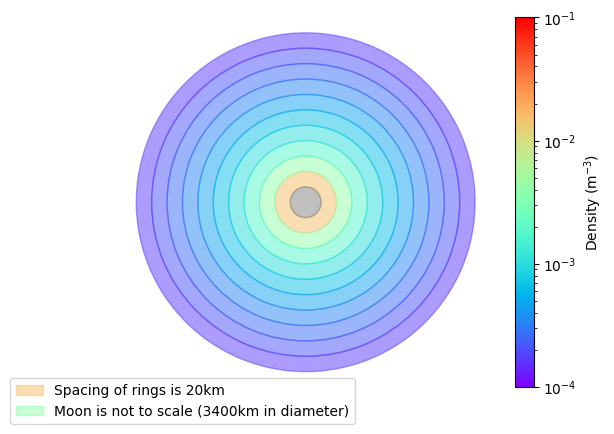

In [6]:
from matplotlib.patches import Annulus
from matplotlib import colors
newR= 20000
moon = plt.Circle((0, 0), newR, color='gray', alpha=0.5)
#heights = [n*10000 for n in range(1, 21)]
heights = [n*20000 for n in range(1, 11)]
values = [calculateDensity(R+h) for h in heights]
cmap = plt.get_cmap('rainbow')
norm = colors.LogNorm(1e-4, 1e-1)

fig, ax = plt.subplots()
for h, v in zip(heights, values):
    color = cmap(norm(v))
    annulus = Annulus(xy=(0, 0), r=h+newR, width=20000, color=color, alpha=0.5)
    ax.add_patch(annulus)

ax.add_patch(moon)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Density ($\\mathrm{m}^{-3}$)')

ax.set_xlim(-220000-newR, 220000+newR)
ax.set_ylim(-220000-newR, 220000+newR)
ax.set_facecolor('white')
ax.set_aspect('equal')
#plt.title('Visual Representation of Dust Density around the Moon')
plt.axis('off')
plt.legend(["Spacing of rings is 20km", "Moon is not to scale (3400km in diameter)"], loc=(-0.3, -0.1))
plt.savefig('Plots/Density_20km_spacing.png')
plt.show()

In [8]:
print(calculateDensity(R+2)/1e6)

1.4819870223797709


C:\Users\james\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
